[*********************100%***********************]  1 of 1 completed


Training on GOOG...
Epoch 10 | Loss: 3.7000
Epoch 20 | Loss: 3.7176
Epoch 30 | Loss: 3.7875
Epoch 40 | Loss: 3.8948
Epoch 50 | Loss: 3.5868
Epoch 60 | Loss: 3.7904
Epoch 70 | Loss: 3.5295
Epoch 80 | Loss: 3.5849
Epoch 90 | Loss: 3.7638
Epoch 100 | Loss: 3.5750

Final Algo: $17057.99
Final Buy & Hold: $17057.99


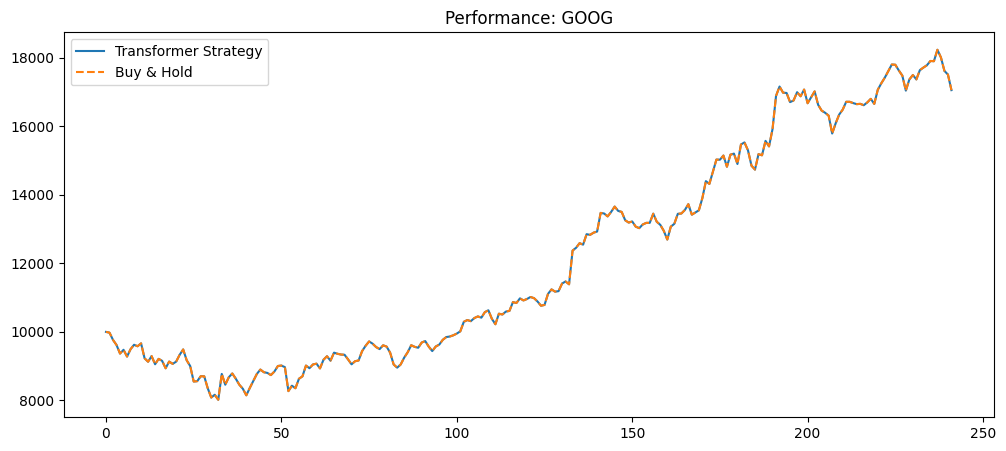

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

TICKER = "GOOG"
SEQ_LENGTH = 30  
DELAY_DAYS = 1   
EPOCHS = 100
LR = 5e-4
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

FEATURES = ["Open", "High", "Low", "Close", "Volume", "RSI", "MACD", "VOL"]

def add_indicators(df):
    # Log Returns
    df["RET"] = np.log(df["Close"] / df["Close"].shift(1))
    # RSI
    delta = df["Close"].diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / (loss + 1e-9)
    df["RSI"] = 100 - (100 / (1 + rs))
    # MACD
    df["MACD"] = df["Close"].ewm(span=12).mean() - df["Close"].ewm(span=26).mean()
    # Volatility
    df["VOL"] = df["RET"].rolling(20).std()
    return df.dropna()

class StockTransformer(nn.Module):
    def __init__(self, feature_dim, embed_dim=128, heads=8, layers=4):
        super().__init__()
        self.input_proj = nn.Linear(feature_dim, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, SEQ_LENGTH, embed_dim))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=heads, dim_feedforward=512, dropout=0.2, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, layers)
        self.fc = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.input_proj(x) + self.pos_embed
        x = self.encoder(x)
        return self.fc(x[:, -1])

def run_project():
    df = yf.download(TICKER, period="5y", auto_adjust=True)
    df = add_indicators(df)
    
    # Sequence Creation (Target = Return * 100)
    data = df[FEATURES].values
    rets = df["RET"].values * 100  # Scaling up for gradient health
    
    X, y = [], []
    for i in range(SEQ_LENGTH, len(df) - DELAY_DAYS):
        X.append(data[i-SEQ_LENGTH:i])
        y.append(rets[i+DELAY_DAYS])
    
    X, y = np.array(X), np.array(y)
    split = int(len(X) * 0.8)
    
    # Scaling (Avoids look-ahead bias)
    scaler = StandardScaler()
    X_train_flat = scaler.fit_transform(X[:split].reshape(-1, len(FEATURES)))
    X_train = X_train_flat.reshape(-1, SEQ_LENGTH, len(FEATURES))
    X_test = scaler.transform(X[split:].reshape(-1, len(FEATURES))).reshape(-1, SEQ_LENGTH, len(FEATURES))
    
    train_loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.Tensor(y[:split])), batch_size=BATCH_SIZE, shuffle=True)
    
    # Training
    model = StockTransformer(len(FEATURES)).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    criterion = nn.MSELoss()
    
    print(f"Training on {TICKER}...")
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE).unsqueeze(1)
            optimizer.zero_grad()
            preds = model(xb)
            
            # Custom Directional Penalty: Loss = MSE + 0.5 * (if signs don't match)
            mse_loss = criterion(preds, yb)
            dir_penalty = torch.mean(torch.relu(-preds * yb)) # Penalizes opposite signs
            loss = mse_loss + dir_penalty
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")

    # Backtest
    model.eval()
    with torch.no_grad():
        test_preds = model(torch.Tensor(X_test).to(DEVICE)).cpu().numpy().flatten()
    
    actual_rets = y[split:] / 100
    pred_rets = test_preds / 100
    
    # If pred > 0, Buy. If pred < 0, Sell.
    algo_equity = [10000]
    bh_equity = [10000] # Buy & Hold Benchmark
    
    for i in range(len(actual_rets)):
        # Algo strategy
        signal = 1 if pred_rets[i] > 0 else 0 
        algo_equity.append(algo_equity[-1] * (1 + signal * actual_rets[i]))
        # Buy and Hold
        bh_equity.append(bh_equity[-1] * (1 + actual_rets[i]))

    print(f"\nFinal Algo: ${algo_equity[-1]:.2f}")
    print(f"Final Buy & Hold: ${bh_equity[-1]:.2f}")

    plt.figure(figsize=(12,5))
    plt.plot(algo_equity, label="Transformer Strategy")
    plt.plot(bh_equity, label="Buy & Hold", linestyle="--")
    plt.legend()
    plt.title(f"Performance: {TICKER}")
    plt.show()

if __name__ == "__main__":
    run_project()